# Cell Sphere Sim Workflow Demo

This notebook shows a basic workflow:

1) set model parameters
2) initialize and run a simulation
3) save outputs to disk
4) run a couple simple analyses

In [1]:
from pathlib import Path

import numpy as np

from cell_sphere_sim.engine import SimulationEngine, SimParams
from cell_sphere_sim.io.stores import TrajectoryStore
from cell_sphere_sim.state import StateTable

In [2]:
def random_points_on_sphere(rng: np.random.Generator, n: int, R_E: float) -> np.ndarray:
    v = rng.normal(size=(n, 3))
    v /= np.linalg.norm(v, axis=1)[:, None]
    return R_E * v


def random_tangent_polarity(rng: np.random.Generator, x: np.ndarray, R_E: float) -> np.ndarray:
    n = x / R_E
    g = rng.normal(size=x.shape)
    g = g - (np.einsum("ij,ij->i", g, n)[:, None]) * n
    g_norm = np.linalg.norm(g, axis=1)
    g_norm = np.where(g_norm > 1e-12, g_norm, 1.0)
    return g / g_norm[:, None]

In [17]:
# (i) Set model parameters
rng = np.random.default_rng(123)
N = 1000
R_E = 500.0

state_table = StateTable(
    R=np.array([15.0]),
    Fm=np.array([1.0]),
    Dr=np.array([0.05]),
    fcil=np.array([2.0]),
    w=np.array([0.2]),
    lambda_div=np.array([0.0]),
    tau_div=np.array([1.0]),
)

params = SimParams(
    R_E=R_E,
    gamma_s=1.0,
    k_rep=2.0,
    alpha_dmin=0.5,
    eps=1e-8,
    dt=0.01,
    neighbor_cell_size=31.0,
    record_interval=1,
    division_enabled=False,
)

# (ii) Initialize and run a simulation
x = random_points_on_sphere(rng, N, R_E)
p = random_tangent_polarity(rng, x, R_E)
state_id = np.zeros((N,), dtype=np.int32)
state_vars = np.zeros((N, 0), dtype=float)

engine = SimulationEngine(x, p, state_id, state_vars, state_table, params, rng=rng)
store = TrajectoryStore()
engine.run(n_steps=1000, t0=0.0, store=store)

len(store.t)

1000

In [23]:
engine.contact_metrics

ContactMetrics(contact_count=array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 

In [18]:
# (iii) Save model outputs to disk
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "minimal_run.npz"

np.savez_compressed(
    output_path,
    t=np.asarray(store.t, dtype=float),
    x=np.array(store.x, dtype=object),
    p=np.array(store.p, dtype=object),
    state_id=np.array(store.state_id, dtype=object),
    state_vars=np.array(store.state_vars, dtype=object),
)

output_path

PosixPath('outputs/minimal_run.npz')

In [10]:
x_list

[array([[-403.9600159760797, 85.68435346682357, -281.9122151726986],
        [46.20374236044635, -268.24786707589305, 419.41422961211447],
        [-356.00517253369003, 303.1407619703427, -177.10447640107128],
        ...,
        [-46.48012193388414, 82.72134210749563, -490.91422654568277],
        [-295.65969052344263, -76.5738977419504, -395.88102453159763],
        [-86.26110663538206, 465.33884566756353, 161.30337936577357]],
       shape=(1000, 3), dtype=object),
 array([[-403.9666308033179, 85.65411980632494, -281.91192411393234],
        [46.207962513411175, -268.25528626934465, 419.40901944153654],
        [-355.9979582378015, 303.141245547914, -177.1181497706425],
        ...,
        [-46.46760175078265, 82.71317883614462, -490.91678728105296],
        [-295.6864507758892, -76.56012006462335, -395.8637023563136],
        [-86.2563088825134, 465.34232196739714, 161.29591614159276]],
       shape=(1000, 3), dtype=object),
 array([[125.28863094333161, -377.59295369347365, -302.

In [19]:
# Load results back and run simple analyses
data = np.load(output_path, allow_pickle=True)
t = data["t"]
x_list = list(data["x"])

# Analysis 1: mean speed per frame
dt = float(params.dt)
mean_speed = []
for i in range(1, len(x_list)):
    dx = x_list[i].astype(float) - x_list[i - 1].astype(float)
    speed = np.linalg.norm(dx, axis=1) / dt
    mean_speed.append(float(np.mean(speed)))

# Analysis 2: radius error at the final frame
x_last = x_list[-1].astype(float)
radius_err = float(np.max(np.abs(np.linalg.norm(x_last, axis=1) - R_E)))

mean_speed[:5], radius_err

([4582.011551896317,
  2953.9269727317223,
  1132.2711410200984,
  426.3492763308215,
  564.5590325123464],
 1.1368683772161603e-13)

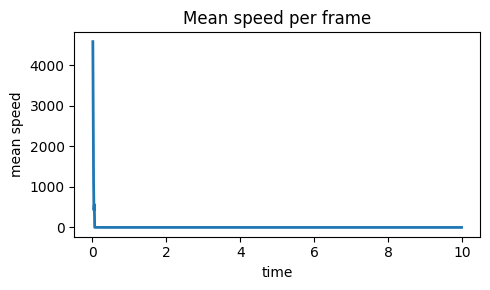

In [20]:
# Optional: plot mean speed over time (requires matplotlib)
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.plot(t[1:], mean_speed, lw=2)
plt.xlabel("time")
plt.ylabel("mean speed")
plt.title("Mean speed per frame")
plt.tight_layout()
plt.show()